In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
X = pd.read_csv("../data/processed/scaled_features.csv")

In [4]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

In [5]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

In [6]:
kmeans = KMeans(
    n_clusters = 4,
    random_state=42,
    n_init=10
)

pca_df["cluster"] = kmeans.fit_predict(X)

c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


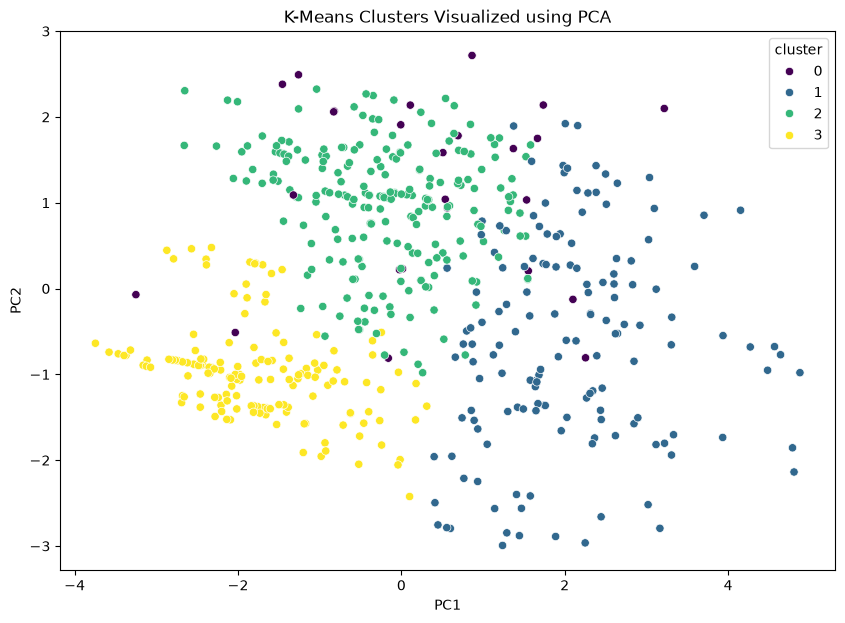

In [7]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis"
)

plt.title("K-Means Clusters Visualized using PCA")
plt.show()

### Explained variance

In [8]:
print("PC1 variance:", pca.explained_variance_ratio_[0])

print("PC2 variance:", pca.explained_variance_ratio_[1])

PC1 variance: 0.2254434288157314
PC2 variance: 0.1201635447596251


In [9]:
total_variance = (
    pca.explained_variance_ratio_.sum()
)

print("Total explained variance:", total_variance)

Total explained variance: 0.3456069735753565


### PCA components

In [10]:
components = pd.DataFrame(
    pca.components_,
    columns = X.columns,
    index = ["PC1","PC2"]
)

components

,price,area,bedrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
PC1,0.510596,0.371211,0.273966,0.262246,0.293009,0.254935,0.216948,0.160242,0.022645,0.306130,0.254826,0.105048,-0.252732
PC2,-0.091666,-0.087440,-0.110439,-0.282134,0.008740,-0.026797,0.085293,0.233709,0.163781,-0.256458,-0.018674,0.641971,-0.569557
